# **TCC - PERFIS DE DESEMPENHO NO ENEM(2018–2023) EM MUNICÍPIOS DA ÁREA DE ABRANGÊNCIA DO IFNMG**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

### Realizando a leitura da base de área de abrangencia do IFNMG

In [2]:
#Base com dados já convertidos em ordinal
df_final = pd.read_csv("BASES\ENEM_FINAL.csv")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,1.0,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,0.0,0.0,0.0,1.0,1.0,0.0,3.0,0.0,0.0,0.0
1,2018,2,0.0,0.0,3,1,2,2,1.0,São Francisco,...,0.0,0.0,0.0,1.0,1.0,0.0,3.0,0.0,0.0,1.0
2,2018,2,1.0,0.0,3,1,2,2,1.0,Montalvânia,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0
3,2018,3,0.0,0.0,1,1,2,2,1.0,Teófilo Otoni,...,1.0,0.0,0.0,1.0,0.0,1.0,4.0,0.0,1.0,1.0
4,2018,3,1.0,0.0,1,1,2,1,1.0,Januária,...,0.0,0.0,0.0,2.0,1.0,0.0,3.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59749,2023,3,1.0,0.0,3,1,2,2,1.0,Pedra Azul,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
59750,2023,3,0.0,1.0,3,1,2,2,1.0,Montes Claros,...,1.0,0.0,1.0,1.0,0.0,1.0,4.0,0.0,2.0,1.0
59751,2023,4,1.0,1.0,1,1,2,2,NaN,Teófilo Otoni,...,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0
59752,2023,2,1.0,1.0,3,1,2,2,1.0,Montes Claros,...,1.0,0.0,1.0,1.0,1.0,0.0,4.0,1.0,2.0,1.0


### **Variancia antes da normalização**

In [3]:
variancia_antes = df_final.var(numeric_only=True)

print("Variância antes da normalização:")
print(variancia_antes)

Variância antes da normalização:
NU_ANO                    3.031808e+00
TP_FAIXA_ETARIA           1.461438e+00
TP_SEXO                   2.387961e-01
TP_ESTADO_CIVIL           2.441612e-01
TP_COR_RACA               8.741702e-01
TP_NACIONALIDADE          5.515295e-02
TP_ST_CONCLUSAO           4.930463e-32
TP_ESCOLA                 1.977703e-01
TP_ENSINO                 6.838446e-02
TP_DEPENDENCIA_ADM_ESC    6.142500e-01
TP_LOCALIZACAO_ESC        8.401000e-02
TP_SIT_FUNC_ESC           3.294882e-03
TP_PRESENCA_CN            4.321919e-02
TP_PRESENCA_CH            2.727592e-03
TP_PRESENCA_LC            2.727592e-03
TP_PRESENCA_MT            4.321919e-02
NU_NOTA_CN                5.517548e+03
NU_NOTA_CH                7.478686e+03
NU_NOTA_LC                5.048718e+03
NU_NOTA_MT                1.161991e+04
TP_LINGUA                 2.488850e-01
TP_STATUS_REDACAO         6.634015e-01
NU_NOTA_COMP1             1.283626e+03
NU_NOTA_COMP2             2.909063e+03
NU_NOTA_COMP3             2.133

### **Aplicando o StandardScaler**

A função normaliza os dados transformando-os para que tenham média 0 e desvio padrão 1.Isso é útil para algoritmos de aprendizado de máquina que são sensíveis à escala das variáveis.

In [4]:
df_scaler = df_final
excluir = ["NO_MUNICIPIO_ESC", "SG_UF_ESC"]

colunas_para_escalar = [c for c in df_scaler.columns if c not in excluir]

scaler = StandardScaler()
df_scaler[colunas_para_escalar] = scaler.fit_transform(df_scaler[colunas_para_escalar])
df_scaler

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,-1.057329,0.202946,1.239846,-1.423650,-2.544830,-0.16839,0.0,-0.286002,-0.138989,Rio Pardo de Minas,...,-0.821463,-0.110088,-0.318919,-0.305989,1.557793,-0.472082,0.457252,-0.312185,-0.861438,-1.805043
1,-1.057329,-0.624259,-0.806552,-1.423650,0.663853,-0.16839,0.0,-0.286002,-0.138989,São Francisco,...,-0.821463,-0.110088,-0.318919,-0.305989,1.557793,-0.472082,0.457252,-0.312185,-0.861438,0.554003
2,-1.057329,-0.624259,1.239846,-1.423650,0.663853,-0.16839,0.0,-0.286002,-0.138989,Montalvânia,...,-0.821463,-0.110088,-0.318919,-0.305989,-0.641934,-0.472082,-0.483196,-0.312185,0.480918,0.554003
3,-1.057329,0.202946,-0.806552,-1.423650,-1.475269,-0.16839,0.0,-0.286002,-0.138989,Teófilo Otoni,...,1.190450,-0.110088,-0.318919,-0.305989,-0.641934,2.118276,1.397700,-0.312185,0.480918,0.554003
4,-1.057329,0.202946,1.239846,-1.423650,-1.475269,-0.16839,0.0,-2.534659,-0.138989,Januária,...,-0.821463,-0.110088,-0.318919,1.259546,1.557793,-0.472082,0.457252,3.203232,0.480918,0.554003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59749,1.814263,0.202946,1.239846,-1.423650,0.663853,-0.16839,0.0,-0.286002,-0.138989,Pedra Azul,...,-0.821463,-0.110088,-0.318919,-1.871525,-0.641934,-0.472082,-1.423644,-0.312185,-0.861438,-1.805043
59750,1.814263,0.202946,-0.806552,0.600139,0.663853,-0.16839,0.0,-0.286002,-0.138989,Montes Claros,...,1.190450,-0.110088,3.135588,-0.305989,-0.641934,2.118276,1.397700,-0.312185,1.823274,0.554003
59751,1.814263,1.030151,1.239846,0.600139,-1.475269,-0.16839,0.0,-0.286002,NaN,Teófilo Otoni,...,1.190450,-0.110088,-0.318919,-1.871525,-0.641934,-0.472082,0.457252,-0.312185,-0.861438,0.554003
59752,1.814263,-0.624259,1.239846,0.600139,0.663853,-0.16839,0.0,-0.286002,-0.138989,Montes Claros,...,1.190450,-0.110088,3.135588,-0.305989,1.557793,-0.472082,1.397700,3.203232,1.823274,0.554003


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **Normalizando as notas e calculando o k só com as notas.**
Para definir o número ideal de clusters (k) no algoritmo K-Means, utilizaremos dois métodos complementares: o método do cotovelo e o método da silhueta.

O **método do cotovelo** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula a soma dos erros quadráticos dentro dos clusters (inertia) para diferentes valores de k. O ponto em que a redução do erro começa a diminuir de forma menos acentuada — formando um “cotovelo” no gráfico — indica o valor ideal de k.

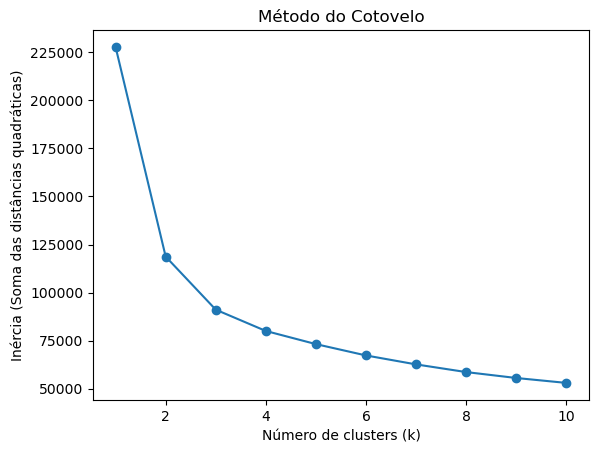

In [5]:
df_notas = df_final
notas = df_notas[["NU_NOTA_CN",	"NU_NOTA_CH",	"NU_NOTA_LC", "NU_NOTA_MT"]]

# Remover linhas com NaN nas colunas de notas
notas = notas.dropna()

# Normalizar
scaler = StandardScaler()
notas_normalizadas = scaler.fit_transform(notas)

# Testar diferentes valores de k
inercia = []
K = range(1, 11)  # de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(notas_normalizadas)
    inercia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (Soma das distâncias quadráticas)")
plt.title("Método do Cotovelo")
plt.show()

O **método da silhueta** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula o coeficiente de silhueta para cada ponto, que mede o quão próximo ele está de pontos do mesmo cluster em comparação com pontos de outros clusters. Valores de silhueta próximos de 1 indicam que o ponto está bem classificado e valores próximos de 0 indicam sobreposição entre clusters.

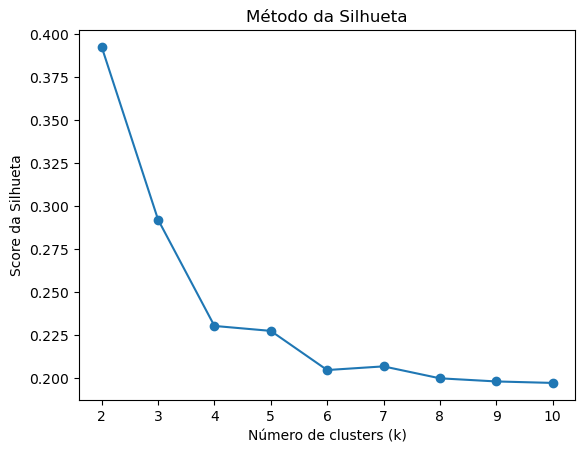

In [6]:
# Calcular os scores de silhueta para diferentes k
silhueta_scores = []
K = range(2, 11)  # começa do 2 porque silhueta não faz sentido para k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(notas_normalizadas)
    score = silhouette_score(notas_normalizadas, labels)
    silhueta_scores.append(score)

# Plotar gráfico da silhueta
plt.plot(K, silhueta_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score da Silhueta")
plt.title("Método da Silhueta")
plt.show()

## **Algumas variáveis [sexo, faixa etaria, tipo de escola e escolaridade e renda]**

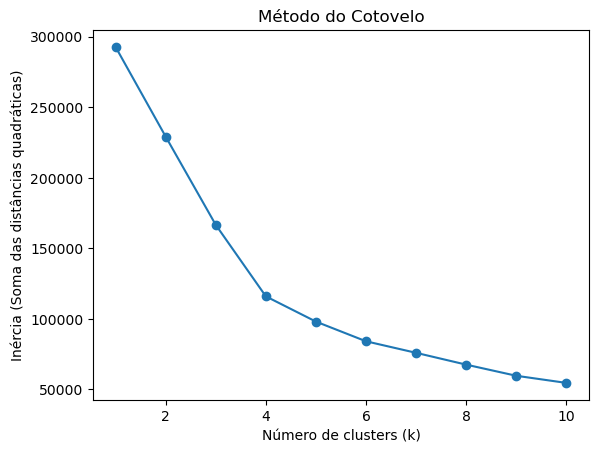

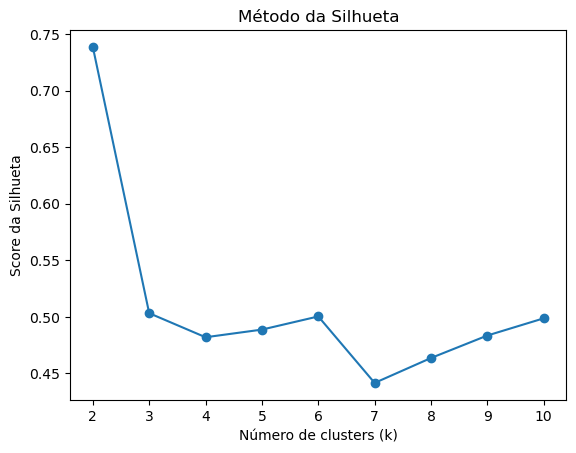

In [7]:
df = df_final

# Selecionar apenas as variáveis desejadas
variaveis = df[["TP_SEXO", "TP_FAIXA_ETARIA", "TP_ESCOLA", "TP_ENSINO", "RENDA_MENSAL"]]

# Remover linhas com NaN nas colunas
variaveis = variaveis.dropna()

# Transformar variáveis categóricas em dummies (one-hot encoding)
variaveis_encoded = pd.get_dummies(variaveis, drop_first=True)

# Normalizar (opcional, mas ajuda o KMeans)
scaler = StandardScaler()
variaveis_normalizadas = scaler.fit_transform(variaveis_encoded)

# Testar diferentes valores de k
inercia = []
K = range(1, 11)  # de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(variaveis_normalizadas)
    inercia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (Soma das distâncias quadráticas)")
plt.title("Método do Cotovelo")
plt.show()

# Calcular silhueta para diferentes k
silhueta_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(variaveis_normalizadas)
    score = silhouette_score(variaveis_normalizadas, labels)
    silhueta_scores.append(score)

# Plotar gráfico da silhueta
plt.plot(K, silhueta_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score da Silhueta")
plt.title("Método da Silhueta")
plt.show()